In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [17]:
df = pd.read_csv("Cleaned/finaldataset.csv")
df.head()

,date,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,1954-07-01,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,1954-08-01,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,1954-09-01,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,1954-10-01,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,1954-11-01,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [18]:
if 'date' in df.columns:
    df.drop('date', axis=1, inplace=True)

In [19]:
X = df.drop(columns=["FEDRates"])
y = df["FEDRates"]

In [25]:
X.head()
# X.to_csv("DTData.csv", index=False) 

In [24]:
y.head()

0    0.80
1    1.22
2    1.07
3    0.85
4    0.83
Name: FEDRates, dtype: float64

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [22]:
print("Training Set:", X_train.shape, y_train.shape)
print("Testing Set:", X_test.shape, y_test.shape)

Training Set: (676, 8) (676,)
Testing Set: (170, 8) (170,)


## Implelemting Decision Tree

In [27]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [28]:
y_pred = dt_model.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [31]:
print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation:
Mean Squared Error (MSE): 1.2909
R² Score: 0.9159


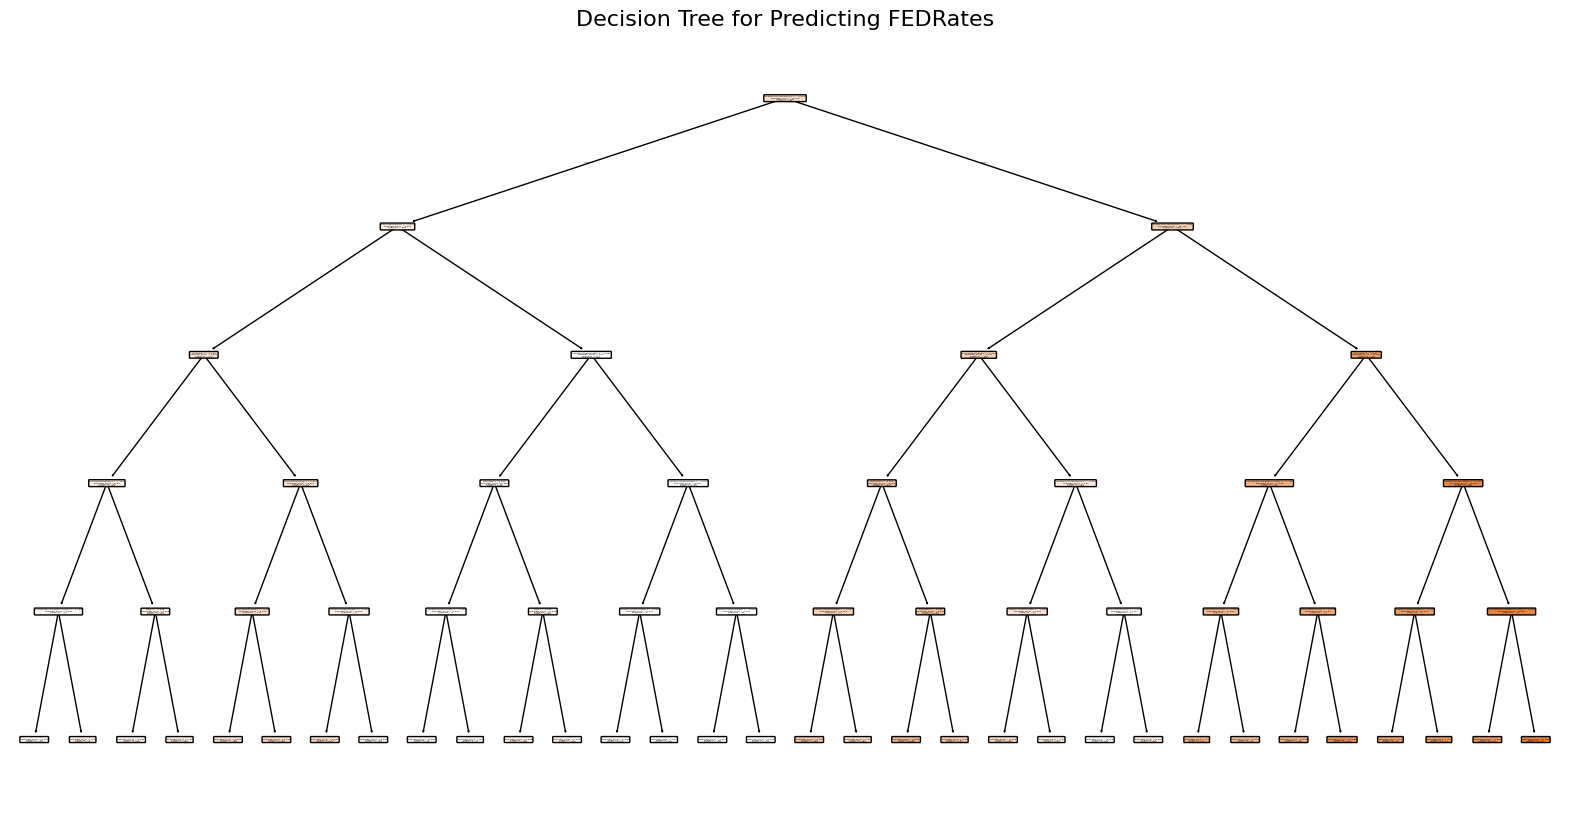

In [32]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, filled=True, rounded=True)
plt.title("Decision Tree for Predicting FEDRates", fontsize=16)
plt.show()

In [33]:
tree_configs = [
    {"max_depth": 4, "criterion": "squared_error", "splitter": "best"},
    {"max_depth": 5, "criterion": "absolute_error", "splitter": "best"},
    {"max_depth": 6, "criterion": "squared_error", "splitter": "random"}
]

In [34]:
def train_and_evaluate(config):
    model = DecisionTreeRegressor(**config, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return model, mse, r2

In [35]:
models = []
for config in tree_configs:
    model, mse, r2 = train_and_evaluate(config)
    models.append((model, config, mse, r2))

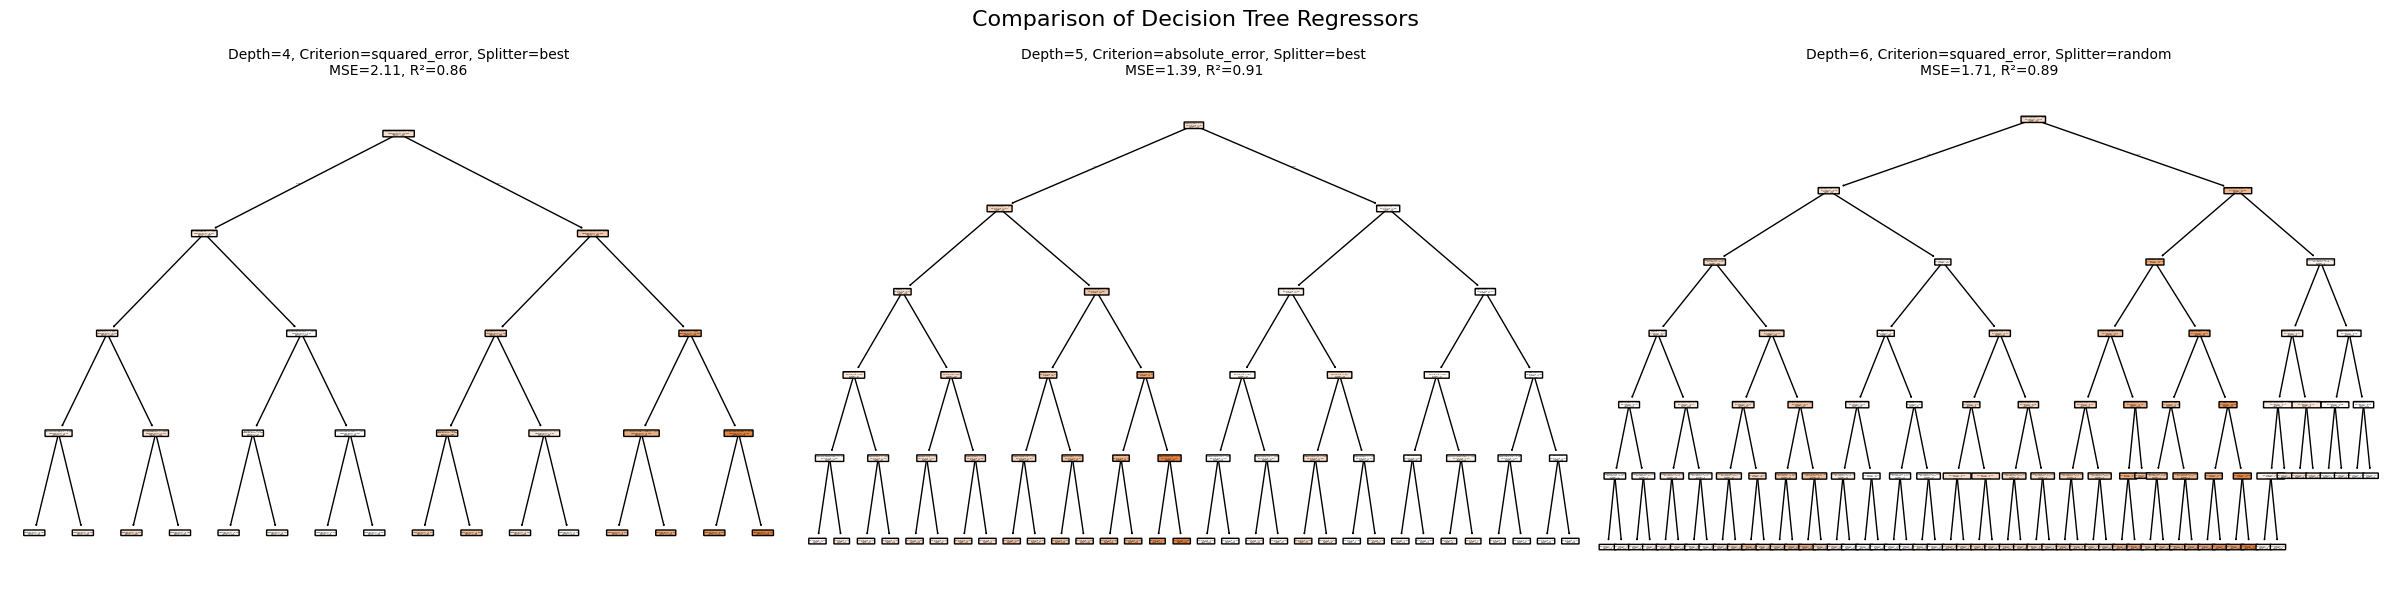

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for i, (model, config, mse, r2) in enumerate(models):
    plot_tree(model, feature_names=X.columns, filled=True, rounded=True, ax=axes[i])
    axes[i].set_title(
        f'Depth={config["max_depth"]}, Criterion={config["criterion"]}, Splitter={config["splitter"]}\n'
        f'MSE={mse:.2f}, R²={r2:.2f}',
        fontsize=10
    )
plt.suptitle("Comparison of Decision Tree Regressors", fontsize=16)
plt.tight_layout()
plt.show()

In [38]:
summary = pd.DataFrame({
    "Tree": [f"Tree {i+1}" for i in range(3)],
    "Max Depth": [cfg["max_depth"] for _, cfg, _, _ in models],
    "Criterion": [cfg["criterion"] for _, cfg, _, _ in models],
    "Splitter": [cfg["splitter"] for _, cfg, _, _ in models],
    "MSE": [mse for _, _, mse, _ in models],
    "R² Score": [r2 for _, _, _, r2 in models]
})

print("Decision Tree Model Comparison:")
print(summary)

Decision Tree Model Comparison:
     Tree  Max Depth       Criterion Splitter       MSE  R² Score
0  Tree 1          4   squared_error     best  2.113937  0.862216
1  Tree 2          5  absolute_error     best  1.385871  0.909671
2  Tree 3          6   squared_error   random  1.705828  0.888816


In [40]:
def bin_fed_rates(values, bins=3):
    return pd.qcut(values, q=bins, labels=["Low", "Medium", "High"])

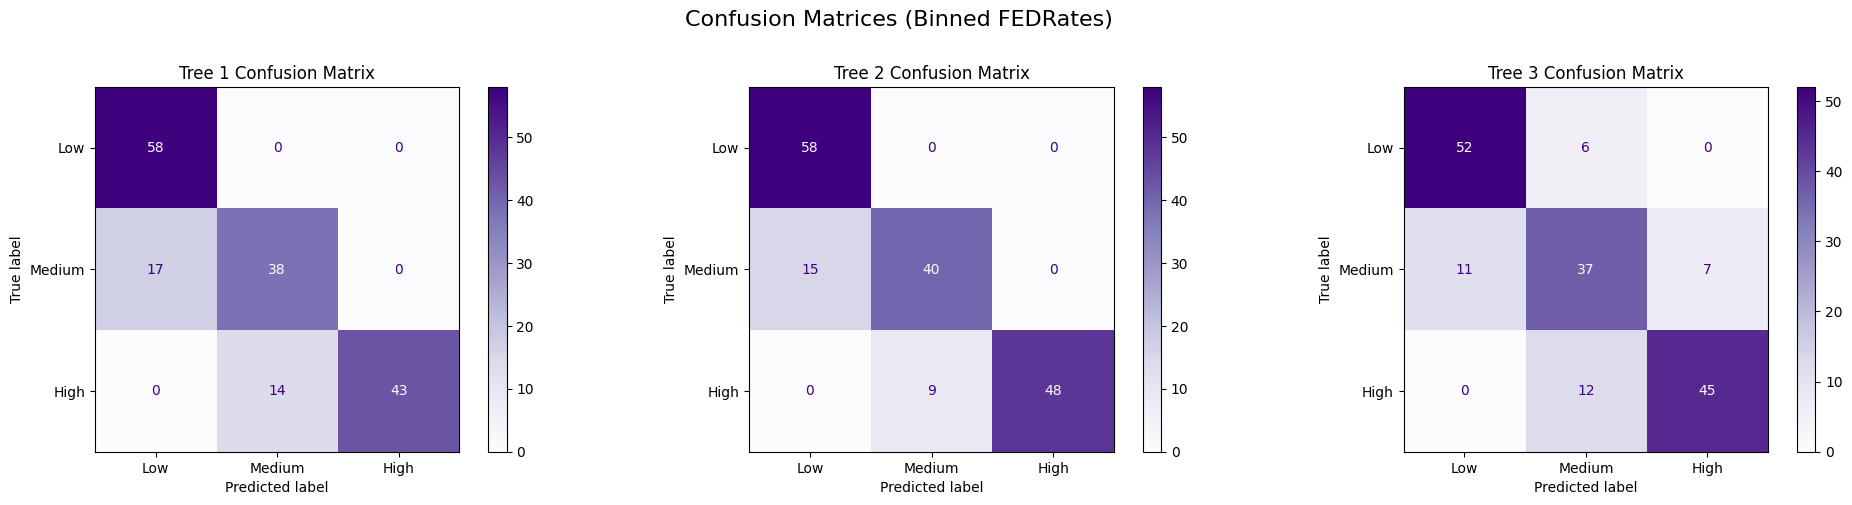

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (model, config, _, _) in enumerate(models):
    # Predict using the model
    y_pred = model.predict(X_test)

    # Bin actual and predicted values
    y_actual_binned = bin_fed_rates(y_test)
    y_pred_binned = bin_fed_rates(y_pred)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual_binned, y_pred_binned, labels=["Low", "Medium", "High"])

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
    disp.plot(ax=axes[i], cmap="Purples", values_format='d')
    axes[i].set_title(f'Tree {i+1} Confusion Matrix')

plt.suptitle("Confusion Matrices (Binned FEDRates)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Decision Tree with different Root Node:

In [44]:
def build_tree_with_forced_root(selected_features, tree_title):
    X_subset = X[selected_features]
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    plt.figure(figsize=(10, 5))
    plot_tree(model, feature_names=selected_features, filled=True, rounded=True)
    plt.title(f"{tree_title}\nMSE = {mse:.2f}, R² = {r2:.2f}")
    plt.show()

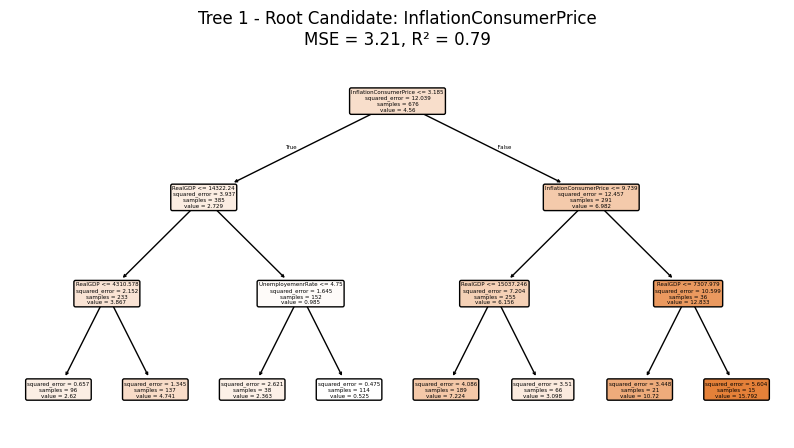

In [45]:
build_tree_with_forced_root(
    ["InflationConsumerPrice", "RealGDP", "UnemployemenrRate"],
    "Tree 1 - Root Candidate: InflationConsumerPrice"
)

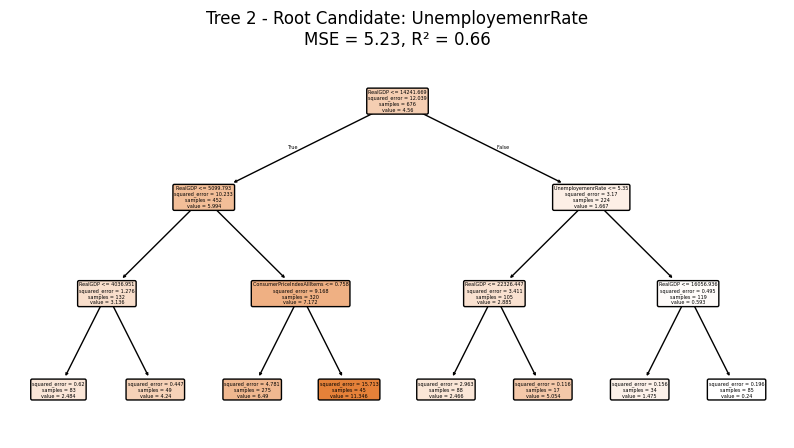

In [46]:
build_tree_with_forced_root(
    ["UnemployemenrRate", "RealGDP", "ConsumerPriceIndexAllItems"],
    "Tree 2 - Root Candidate: UnemployemenrRate"
)

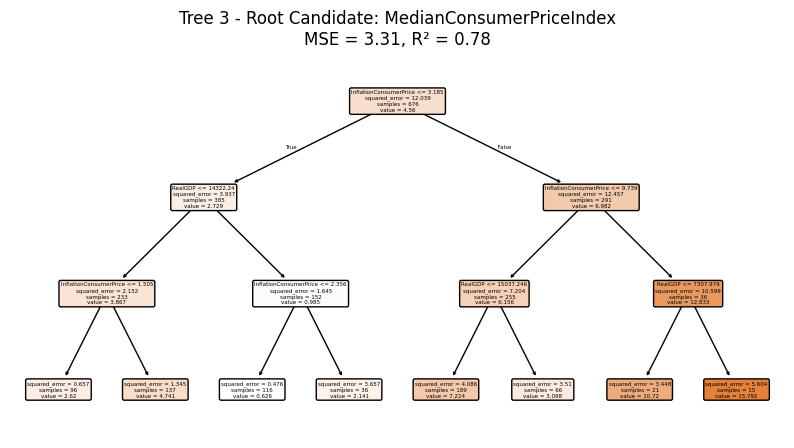

In [47]:
build_tree_with_forced_root(
    ["MedianConsumerPriceIndex", "RealGDP", "InflationConsumerPrice"],
    "Tree 3 - Root Candidate: MedianConsumerPriceIndex"
)

In [48]:
def bin_target(values, n_bins=3):
    return pd.qcut(values, q=n_bins, labels=["Low", "Medium", "High"])

In [49]:
def show_conf_matrix(model, X_features, title):
    X_subset = X[X_features]
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_actual_binned = bin_target(y_test)
    y_pred_binned = bin_target(y_pred)

    cm = confusion_matrix(y_actual_binned, y_pred_binned, labels=["Low", "Medium", "High"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
    disp.plot(cmap="Purples", values_format='d')
    plt.title(title)
    plt.show()

In [50]:
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)

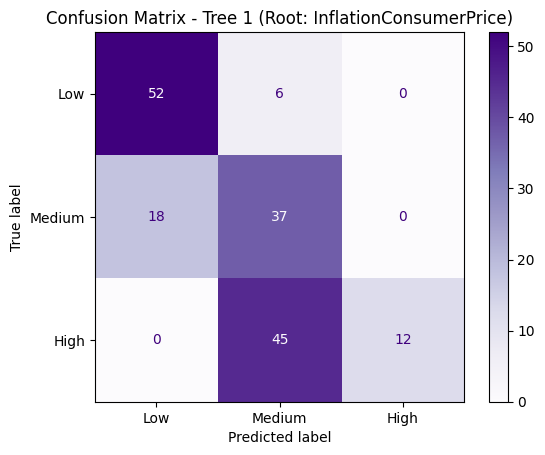

In [51]:
show_conf_matrix(tree_model, ["InflationConsumerPrice", "RealGDP", "UnemployemenrRate"],
                 "Confusion Matrix - Tree 1 (Root: InflationConsumerPrice)")

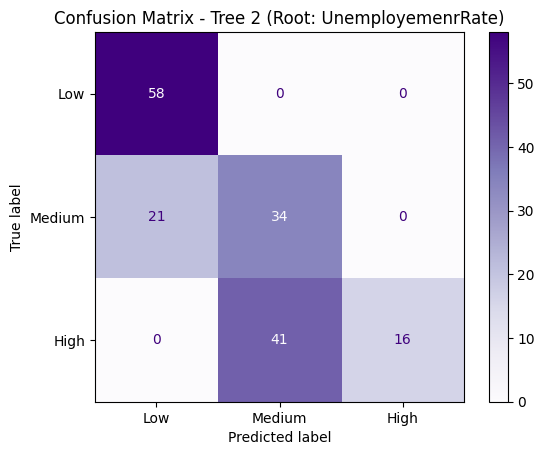

In [52]:
show_conf_matrix(tree_model, ["UnemployemenrRate", "RealGDP", "ConsumerPriceIndexAllItems"],
                 "Confusion Matrix - Tree 2 (Root: UnemployemenrRate)")

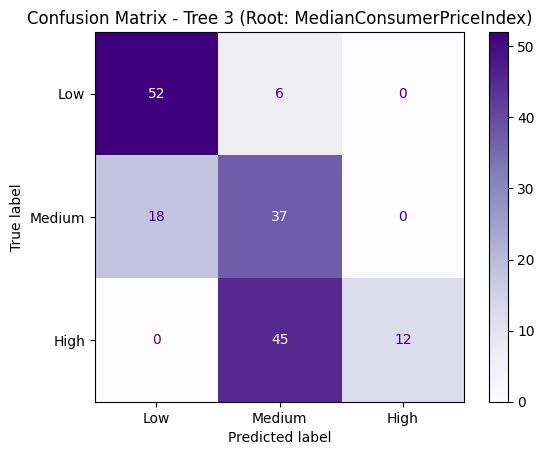

In [53]:
show_conf_matrix(tree_model, ["MedianConsumerPriceIndex", "RealGDP", "InflationConsumerPrice"],
                 "Confusion Matrix - Tree 3 (Root: MedianConsumerPriceIndex)")